In [3]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL, seasonal_decompose

# Triplet Formation

In [4]:
def calculate_correlation(df, detector1, detector2, start_date, end_date):
    # Filter the DataFrame for the given period
    filtered_df = df[start_date:end_date]
    
    # Calculate the correlation
    correlation = filtered_df[detector1].corr(filtered_df[detector2])
    return correlation


In [5]:
df = pd.read_csv('./data/Traffic_Detectors.csv')
df = df.drop(['OBJECTID','Road_TC','Road_SC','Direction'], axis= 1)
df['Bound'] = ['NA' for i in range(786)]
for i in range(786):
    if('Eastbound' in df['Road_EN'][i]):
        df.loc[i,'Bound']='East'
    elif('Westbound' in df['Road_EN'][i]):
        df.loc[i,'Bound']='West'
    elif('Northbound' in df['Road_EN'][i]):
        df.loc[i,'Bound']='North'
    elif('Southbound' in df['Road_EN'][i]):
        df.loc[i,'Bound']='South'

for i in range(786):
    if(df['Bound'][i]=='NA'):
        print(df.loc[i,'Road_EN'])
        print(i)

df.loc[197,'Bound'] = 'North'
df.loc[200,'Bound'] = 'North'
df.loc[210,'Bound'] = 'South'
df.loc[254,'Bound'] = 'West'
df.loc[580,'Bound'] = 'South'
df.loc[735,'Bound'] = 'South'
df.loc[736,'Bound'] = 'South'
df.loc[739,'Bound'] = 'South'
df.loc[746,'Bound'] = 'South'


Kwai Chung Road near Lai King MTR Station - Nouthbound 
197
Tsuen Wan Road near Wing Kin Industrial Building - Nouthbound 
200
Tsuen Wan Road near Tsuen Wan Sports Centre - Sorthbound 
210
Lung Cheung Road near Diamond Hill MTR Station 
254
Tuen Mun Road near Siu Hong MTR Station - Souththbound 
580
Tai Po Road - Yuen Chau Tsai near Kwong Wang Street - Souhtbound 
735
Tai Po Road - Tai Po Kau near Tai Po Kau Fresh Water Pumping Station - Souhtbound 
736
Tai Po Road - Tai Po Kau near Tai Po Kau Garden - Souhtbound 
739
Tai Po Road - Ma Liu Shui near Chek Nai Ping - Souhtbound 
746


In [6]:
df

,AID_ID_Number,District,Road_EN,Rotation,GeometryEasting,GeometryNorthing,Bound
0,AID01101,Southern,Aberdeen Praya Road near Abba House - Eastbound,100,833758,812147,East
1,AID01102,Southern,Aberdeen Praya Road near Hoi Fai Mansion - Eas...,60,834293,812041,East
2,AID01103,Southern,Wong Chuk Hang Road near Aberdeen Technical Sc...,80,834750,812208,East
3,AID01104,Southern,Wong Chuk Hang Road Flyover near AXA Southside...,60,835128,812179,East
4,AID01105,Southern,Wong Chuk Hang Road Flyover near Benefit Indus...,50,835419,812324,East
...,...,...,...,...,...,...,...
781,TDSYSR10002,Tai Po,Yuen Shin Road near Tai Po Tai Wo Road - North...,10,836309,834720,North
782,TDSYSR10003,Tai Po,Yuen Shin Road near Dai Fat Street - Northbound,10,836383,834949,North
783,TDSYSR20001,Tai Po,Yuen Shin Road near Tai Po Tai Wo Road - South...,190,836288,834549,South
784,TDSYSR20002,Tai Po,Yuen Shin Road near Dai Fat Street - Southbound,190,836355,834833,South


In [7]:
from math import radians, cos, sin, asin, sqrt

def distance(lat1, lon1, lat2, lon2):
     
    # The math module contains a function named
    # radians which converts from degrees to radians.
    lon1 = radians(lon1)
    lon2 = radians(lon2)
    lat1 = radians(lat1)
    lat2 = radians(lat2)
      
    # Haversine formula 
    dlon = lon2 - lon1 
    dlat = lat2 - lat1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
 
    c = 2 * asin(sqrt(a)) 
    
    # Radius of earth in kilometers. Use 3956 for miles
    r = 6371
      
    # calculate the result
    return(c * r)

def eucledian_distance(e1,n1,e2,n2):
  
    return sqrt((e1-e2)**2 + (n1-n2)**2)/1000

In [8]:
# df['Distance1']=[0.0 for i in range(700)]
df['Distance2']=[0.0 for i in range(786)]
# df['diff']=[0.0 for i in range(700)]


for i in range(785):
    # df.loc[i,'Distance1'] = float(distance(df.loc[i,'Latitude'],df.loc[i,'Longitude'],df.loc[i+1,'Latitude'],df.loc[i+1,'Longitude']))
    df.loc[i,'Distance2'] = float(eucledian_distance(df.loc[i,'GeometryEasting'],df.loc[i,'GeometryNorthing'],df.loc[i+1,'GeometryEasting'],df.loc[i+1,'GeometryNorthing']))
    # df.loc[i,'diff'] = abs(df.loc[i,'Distance1'] - df.loc[i,'Distance2'])


data = df[['AID_ID_Number', 'Road_EN', 'Distance2', 'Bound', 'District']]

print(data.to_string())

      AID_ID_Number                                                                                         Road_EN  Distance2  Bound             District
0          AID01101                                                Aberdeen Praya Road near Abba House - Eastbound    0.545400   East             Southern
1          AID01102                                           Aberdeen Praya Road near Hoi Fai Mansion - Eastbound    0.486557   East             Southern
2          AID01103                                 Wong Chuk Hang Road near Aberdeen Technical School - Eastbound    0.379111   East             Southern
3          AID01104                                     Wong Chuk Hang Road Flyover near AXA Southside - Eastbound    0.325125   East             Southern
4          AID01105               Wong Chuk Hang Road Flyover near Benefit Industrial Factory Building - Eastbound    0.344401   East             Southern
5          AID01106                             Wong Chuk Hang Road ne

In [7]:
# for i in range(699):
#     if(data.loc[i,'diff']>0.1):
#         print(i)

In [8]:
df

,AID_ID_Number,District,Road_EN,Rotation,GeometryEasting,GeometryNorthing,Bound,Distance2
0,AID01101,Southern,Aberdeen Praya Road near Abba House - Eastbound,100,833758,812147,East,0.545400
1,AID01102,Southern,Aberdeen Praya Road near Hoi Fai Mansion - Eas...,60,834293,812041,East,0.486557
2,AID01103,Southern,Wong Chuk Hang Road near Aberdeen Technical Sc...,80,834750,812208,East,0.379111
3,AID01104,Southern,Wong Chuk Hang Road Flyover near AXA Southside...,60,835128,812179,East,0.325125
4,AID01105,Southern,Wong Chuk Hang Road Flyover near Benefit Indus...,50,835419,812324,East,0.344401
...,...,...,...,...,...,...,...,...
781,TDSYSR10002,Tai Po,Yuen Shin Road near Tai Po Tai Wo Road - North...,10,836309,834720,North,0.240660
782,TDSYSR10003,Tai Po,Yuen Shin Road near Dai Fat Street - Northbound,10,836383,834949,North,0.411127
783,TDSYSR20001,Tai Po,Yuen Shin Road near Tai Po Tai Wo Road - South...,190,836288,834549,South,0.291796
784,TDSYSR20002,Tai Po,Yuen Shin Road near Dai Fat Street - Southbound,190,836355,834833,South,0.349070


In [9]:
# This is the rule for forming Triplets and Duets

correlated_detectors = {}
triplets = []
duets = []
size = len(df)

for i in range(size):
    correlated_detectors[df.loc[i,'AID_ID_Number']]=[]

    lhs=False
    rhs=False
    if((i>0) and (df.loc[i-1,'Distance2'] < 1 and df.loc[i-1,'Bound']==df.loc[i,'Bound'] ) ):
        correlated_detectors[df.loc[i,'AID_ID_Number']].append(df.loc[i-1,'AID_ID_Number'])
        lhs=True
    
    if((i< size-1) and (df.loc[i,'Distance2'] < 1 and df.loc[i,'Bound']==df.loc[i+1,'Bound']) ) :
        correlated_detectors[df.loc[i,'AID_ID_Number']].append(df.loc[i+1,'AID_ID_Number'])
        rhs=True

    if(lhs and rhs):
        triplets.append([df.loc[i-1,'AID_ID_Number'],df.loc[i,'AID_ID_Number'],df.loc[i+1,'AID_ID_Number']])
    
    if(rhs and (not lhs) and (df.loc[i+1,'Distance2'] > 1 or df.loc[i+1,'Bound']!=df.loc[i+2,'Bound'])):
        duets.append([df.loc[i,'AID_ID_Number'],df.loc[i+1,'AID_ID_Number']])
        
    # if((i>1) and (lhs and (not rhs))   ):
    #     if( (df.loc[i-2,'Distance2'] + df.loc[i-1,'Distance2']) < 1.5 and df.loc[i-2,'Bound']==df.loc[i,'Bound'] ):
    #         correlated_detectors[df.loc[i,'AID_ID_Number']].append(df.loc[i-2,'AID_ID_Number'])

    # if((i< size-2) and (rhs and (not lhs)) ):
    #     if( (df.loc[i,'Distance2'] + df.loc[i+1,'Distance2']) < 1.5 and df.loc[i+2,'Bound']==df.loc[i,'Bound'] ):
    #         correlated_detectors[df.loc[i,'AID_ID_Number']].append(df.loc[i+2,'AID_ID_Number'])


In [10]:
# correlated_detectors
triplets

[['AID01101', 'AID01102', 'AID01103'],
 ['AID01102', 'AID01103', 'AID01104'],
 ['AID01103', 'AID01104', 'AID01105'],
 ['AID01104', 'AID01105', 'AID01106'],
 ['AID01105', 'AID01106', 'AID01107'],
 ['AID01108', 'AID01109', 'AID01110'],
 ['AID01111', 'AID01112', 'AID01113'],
 ['AID01112', 'AID01113', 'AID01114'],
 ['AID01113', 'AID01114', 'AID01115'],
 ['AID01114', 'AID01115', 'AID01116'],
 ['AID01115', 'AID01116', 'AID01117'],
 ['AID01116', 'AID01117', 'AID01118'],
 ['AID01117', 'AID01118', 'AID01119'],
 ['AID01118', 'AID01119', 'AID01120'],
 ['AID01119', 'AID01120', 'AID01121'],
 ['AID01120', 'AID01121', 'AID01122'],
 ['AID01121', 'AID01122', 'AID01123'],
 ['AID01124', 'AID01125', 'AID01126'],
 ['AID01125', 'AID01126', 'AID01127'],
 ['AID01126', 'AID01127', 'AID01128'],
 ['AID01127', 'AID01128', 'AID01129'],
 ['AID01128', 'AID01129', 'AID01130'],
 ['AID01129', 'AID01130', 'AID01131'],
 ['AID01130', 'AID01131', 'AID01132'],
 ['AID01131', 'AID01132', 'AID01133'],
 ['AID01132', 'AID01133',

# Analysis

In [21]:
dfs = pd.read_csv("./data/speed_10.23-03.24.csv")
dfv = pd.read_csv("./data/flow_10.23-03.24.csv")
dfo = pd.read_csv("./data/occupancy_10.23-03.24.csv")
dfl = pd.read_csv("./data/lane_10.23-03.24.csv")

In [23]:
dfl = dfl[dfl['speed_lane_count']!=0]
detectors = list(dfl['detector'])
len(detectors)

768

In [ ]:
dfs.loc[:,'timestamp'] = pd.to_datetime(dfs['timestamp'], errors='coerce')
dfs.set_index("timestamp",inplace=True)

dfv.loc[:,'timestamp'] = pd.to_datetime(dfv['timestamp'], errors='coerce')
dfv.set_index("timestamp",inplace=True)

dfo.loc[:,'timestamp'] = pd.to_datetime(dfo['timestamp'], errors='coerce')
dfo.set_index("timestamp",inplace=True)

In [16]:
# dfk = 30 * dfv / dfs

# # Replace infinity values with NaN
# dfk.replace([float('inf'), float('-inf')], float('nan'), inplace=True)

### Using Flow

In [25]:
# To find %of bad detectors

numbers = np.arange(0.7, 0.95 + 0.01, 0.01)
all_timestamps = list(pd.date_range(start='2023-11-01 00:00:00', end='2023-11-30 23:58:00', freq='1d'))

bad_detectors = []

for idx in all_timestamps:
    y = []
    data = dfv.loc[idx:idx + pd.DateOffset(days=1)]
    for cutoff in numbers:

        faulty_flow = []

        for i in triplets:
            lhs = False
            rhs = False
            if( i[0] in detectors and i[1] in detectors):
                corr1 = data[i[0]+'_total_flow'].corr(data[i[1]+'_total_flow'])
                if(corr1<cutoff): lhs = True
            if( i[1] in detectors and i[2] in detectors):
                corr2 = data[i[1]+'_total_flow'].corr(data[i[2]+'_total_flow'])
                if(corr2<cutoff): rhs = True

            if(lhs and (not rhs)): faulty_flow.append(i[0] )
            elif(lhs and rhs): faulty_flow.append(i[1])
            elif(rhs and (not lhs)): faulty_flow.append(i[2])

        faulty_flow = list(set(faulty_flow))
        faulty_flow.sort()
        y.append(len(faulty_flow)*100/589)
    
    bad_detectors.append(y)



    

c:\PROGRAM FILES\PYTHON311\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\PROGRAM FILES\PYTHON311\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [31]:
arrays_np = np.array(bad_detectors)

# Compute the average along the first axis (rows)
average_array = np.mean(arrays_np, axis=0)

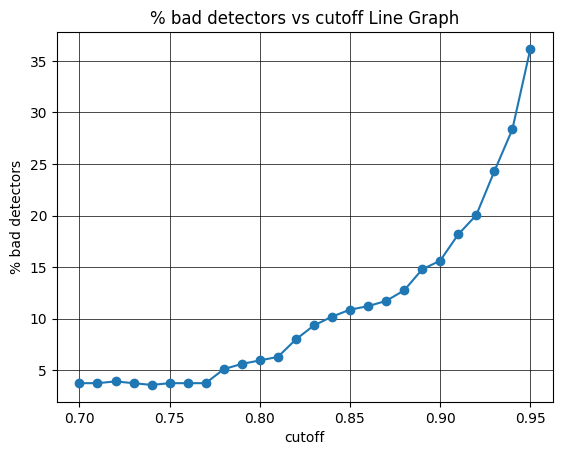

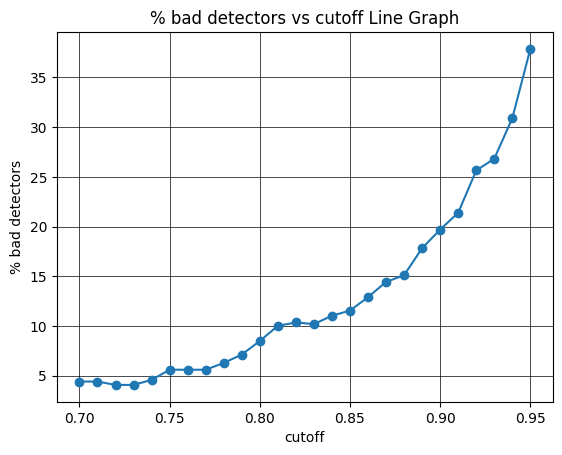

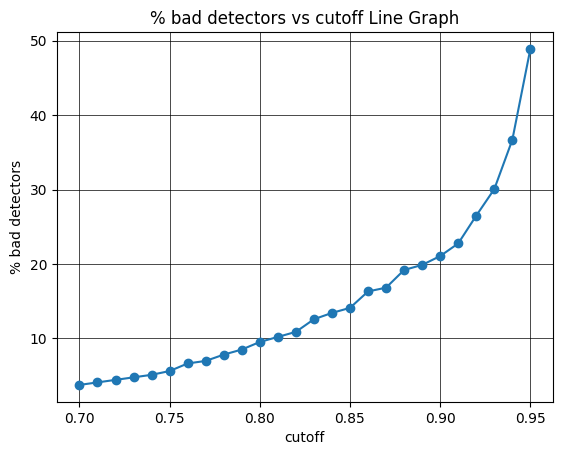

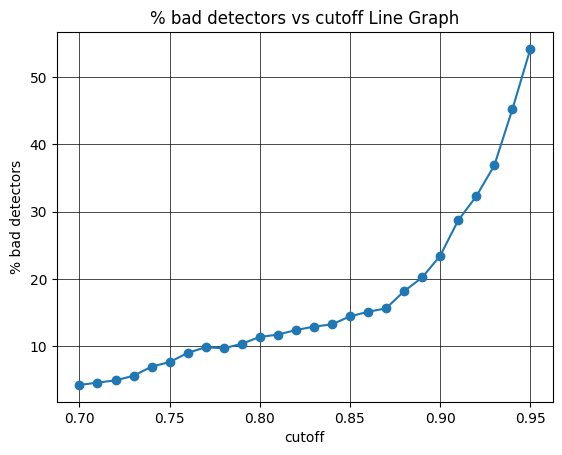

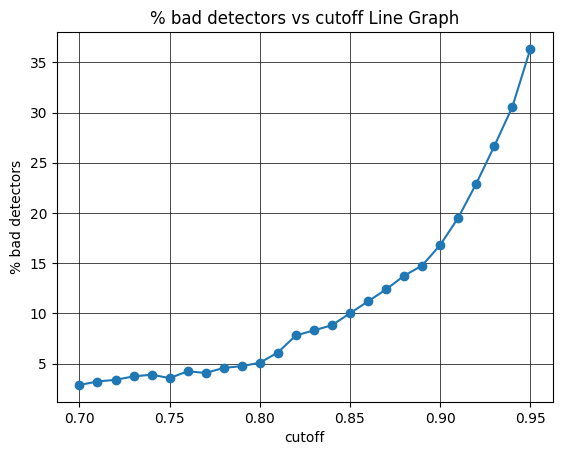

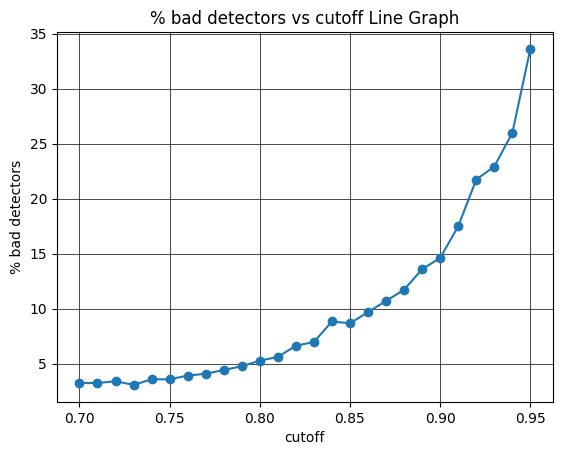

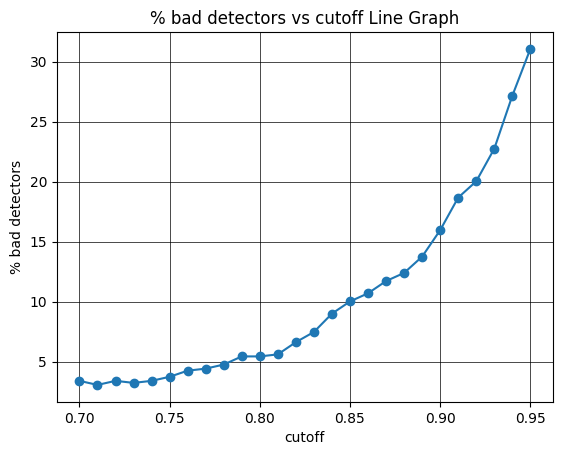

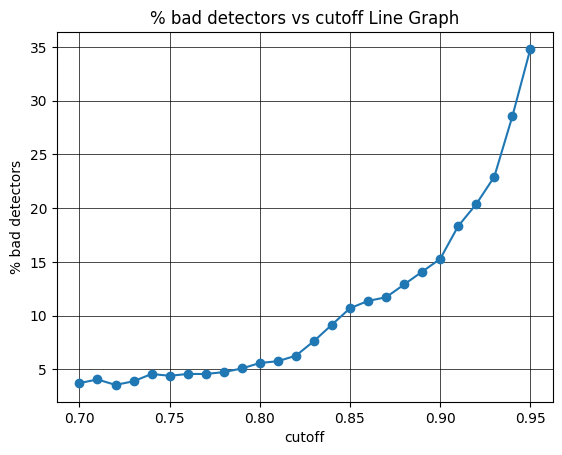

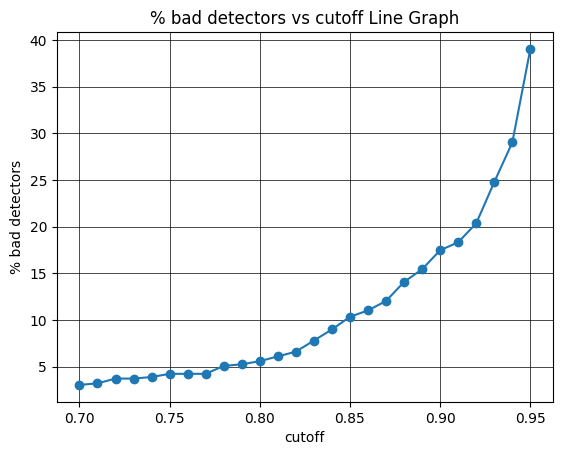

In [32]:
for i in range(1,10):
    plt.plot(numbers,bad_detectors[i] , marker='o')

    plt.title('% bad detectors vs cutoff Line Graph')
    plt.xlabel('cutoff')
    plt.ylabel('% bad detectors')
    plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
    # Show the plot
    plt.show()

In [33]:
# All correlations with their no. of lanes
for key in correlated_detectors:
    if(key+'_total_flow' in dfv.columns):
        values = correlated_detectors[key]
        for val in values:
            if(val+'_total_flow' in dfv.columns):
                corr = dfv[key+'_total_flow'].corr(dfv[val+'_total_flow'])
                print(key + ' with '+ val + ' : ', corr, dfl.loc[dfl['detector'] == key, 'speed_lane_count'].values[0],dfl.loc[dfl['detector'] == val, 'speed_lane_count'].values[0]) 
        print()


AID01101 with AID01102 :  0.9205098320792797 3 3

AID01102 with AID01101 :  0.9205098320792797 3 3
AID01102 with AID01103 :  0.9351398139930697 3 3

AID01103 with AID01102 :  0.9351398139930698 3 3
AID01103 with AID01104 :  0.9446003372678019 3 2

AID01104 with AID01103 :  0.9446003372678018 2 3
AID01104 with AID01105 :  0.9689758942949818 2 2

AID01105 with AID01104 :  0.9689758942949818 2 2
AID01105 with AID01106 :  0.8913018942587696 2 2

AID01106 with AID01105 :  0.8913018942587696 2 2
AID01106 with AID01107 :  0.9306530677911139 2 2

AID01107 with AID01106 :  0.930653067791114 2 2

AID01108 with AID01109 :  0.877353147982047 2 3

AID01109 with AID01108 :  0.877353147982047 3 2
AID01109 with AID01110 :  0.9458943817967406 3 3

AID01110 with AID01109 :  0.9458943817967407 3 3

AID01111 with AID01112 :  0.9796486381364686 4 4

AID01112 with AID01111 :  0.9796486381364687 4 4
AID01112 with AID01113 :  0.9063529808195884 4 3

AID01113 with AID01112 :  0.9063529808195884 3 4
AID01113 wi

In [34]:
faulty = []   #correlations with <0.85 value

for key in correlated_detectors:
    if(key+'_total_flow' in dfv.columns):
        values = correlated_detectors[key]
        for val in values:
            if(val+'_total_flow' in dfv.columns):
                corr = dfv[key+'_total_flow'].corr(dfv[val+'_total_flow'])
                if(corr<0.85):
                    faulty.append(key+'_lane1')
                    print(key + ' with '+ val + ' : ', corr)
        

AID01129 with AID01130 :  0.698584007776831
AID01130 with AID01129 :  0.6985840077768309
AID01130 with AID01131 :  0.688439158239815
AID01131 with AID01130 :  0.688439158239815
AID01212 with AID01213 :  0.4522493038601363
AID01213 with AID01212 :  0.4522493038601363
AID03102 with AID03103 :  0.8027307260434062
AID03103 with AID03102 :  0.8027307260434063
AID03103 with AID03104 :  0.7747005061472602
AID03104 with AID03103 :  0.7747005061472603
AID04201 with AID04202 :  0.2899533990376552
AID04202 with AID04201 :  0.2899533990376552
AID04210 with AID04211 :  0.814916140081704
AID04211 with AID04210 :  0.8149161400817039
AID04219 with AID04220 :  0.8374316885712159
AID04220 with AID04219 :  0.8374316885712159
AID05101 with AID05102 :  0.7301644887779591
AID05102 with AID05101 :  0.730164488777959
AID05103 with AID05104 :  0.8093557387505594
AID05104 with AID05103 :  0.8093557387505596
AID05109 with AID05110 :  0.7490043317246768
AID05110 with AID05109 :  0.7490043317246768
AID05110 with A

In [36]:
faulty = list(set(faulty))
faulty

['AID09106_lane1',
 'AID07102_lane1',
 'TDSPBH10002_lane1',
 'AID04201_lane1',
 'TDSTKR20008_lane1',
 'TDSTYR10002_lane1',
 'TDSTKR20005_lane1',
 'TDSTPR10003_lane1',
 'AID05109_lane1',
 'TDSTTR10001_lane1',
 'AID05104_lane1',
 'AID01130_lane1',
 'TDSTPR10014_lane1',
 'TDSNCWBR10002_lane1',
 'TDS10013_lane1',
 'TDSTCKR10002_lane1',
 'TDSNCWBR20002_lane1',
 'AID08202_lane1',
 'TDS91031_lane1',
 'TDS90024_lane1',
 'TDSYSR20002_lane1',
 'AID07103_lane1',
 'TDSTPTWR20002_lane1',
 'TDSTKR20006_lane1',
 'TDSTKR10004_lane1',
 'AID05103_lane1',
 'AID07232_lane1',
 'TDSNCWBR20001_lane1',
 'TDSJCR10001_lane1',
 'TDS91032_lane1',
 'TDSCPRLT10001_lane1',
 'AID07101_lane1',
 'TDSTKR20001_lane1',
 'TDSNCWBR10003_lane1',
 'TDSTPR20003_lane1',
 'AID05234_lane1',
 'TDSCPRPS20004_lane1',
 'TDSYSR10001_lane1',
 'AID08204_lane1',
 'TDSTPR20009_lane1',
 'AID07109_lane1',
 'TDSTPTWR20001_lane1',
 'TDSTPR20005_lane1',
 'AID05233_lane1',
 'AID03103_lane1',
 'TDSTCKR10004_lane1',
 'TDSTPR10013_lane1',
 'TDS900

In [37]:
removed_df = pd.read_excel('./data/removed_STF.xlsx')
removed = list(removed_df['Removed'])

for i in range(len(removed)):
    removed[i]=removed[i].replace(",", "")

removed

['AID01119_lane1',
 'AID01119_lane2',
 'AID01119_lane3',
 'AID01120_lane1',
 'AID01120_lane2',
 'AID01120_lane3',
 'AID01130_lane1',
 'AID01130_lane2',
 'AID01130_lane3',
 'AID01130_lane4',
 'AID01205_lane1',
 'AID01205_lane2',
 'AID01205_lane3',
 'AID01218_lane3',
 'AID01218_lane4',
 'AID02116_lane3',
 'AID05112_lane2',
 'AID05112_lane3',
 'AID05113_lane1',
 'AID05116_lane3',
 'AID05116_lane4',
 'AID05130_lane1',
 'AID05130_lane2',
 'AID07206_lane1',
 'AID07206_lane2',
 'AID07206_lane3',
 'AID09154_lane1',
 'AID09154_lane2',
 'AID09154_lane3',
 'AID09255_lane1',
 'AID09255_lane2',
 'AID09255_lane3',
 'AID10111_lane1',
 'AID10201_lane1',
 'AID10202_lane1',
 'AID10203_lane1',
 'AID10206_lane1',
 'AID10207_lane1',
 'AID10208_lane1',
 'AID10210_lane1',
 'AID10213_lane1',
 'AID10213_lane2',
 'AID10213_lane3',
 'AID10217_lane1',
 'AID10218_lane1',
 'TDS/CPRPS/10001_lane1',
 'TDS/CPRPS/10001_lane2',
 'TDS/CPRPS/20002_lane1',
 'TDS/CPRPS/20002_lane2',
 'TDS/JCR/20002_lane1',
 'TDS/JCR/20002_l

In [38]:
val=0
for i in faulty:
    if(i in removed):
        val = val+1
val

3

In [39]:
removed_subset = []

for i in removed:
    if('lane1' in i):
        removed_subset.append(i)
print(len(removed_subset))
removed_subset

69


['AID01119_lane1',
 'AID01120_lane1',
 'AID01130_lane1',
 'AID01205_lane1',
 'AID05113_lane1',
 'AID05130_lane1',
 'AID07206_lane1',
 'AID09154_lane1',
 'AID09255_lane1',
 'AID10111_lane1',
 'AID10201_lane1',
 'AID10202_lane1',
 'AID10203_lane1',
 'AID10206_lane1',
 'AID10207_lane1',
 'AID10208_lane1',
 'AID10210_lane1',
 'AID10213_lane1',
 'AID10217_lane1',
 'AID10218_lane1',
 'TDS/CPRPS/10001_lane1',
 'TDS/CPRPS/20002_lane1',
 'TDS/JCR/20002_lane1',
 'TDS/LTR/20002_lane1',
 'TDS/MOSB/10002_lane1',
 'TDS/MOSB/20005_lane1',
 'TDS/MOSR/10003_lane1',
 'TDS/NCWBR/20001_lane1',
 'TDS/NCWBR/20003_lane1',
 'TDS/PBH/10002_lane1',
 'TDS/TCKR/10001_lane1',
 'TDS/TCKR/10002_lane1',
 'TDS/TKR/10007_lane1',
 'TDS/TPR/10009_lane1',
 'TDS/TPTWR/10002_lane1',
 'TDS/TPTWR/20002_lane1',
 'TDS10003_lane1',
 'TDS10006_lane1',
 'TDS10009_lane1',
 'TDS20006_lane1',
 'TDS30006_lane1',
 'TDS30008_lane1',
 'TDS90004_lane1',
 'TDS90019_lane1',
 'TDS90020_lane1',
 'TDS90023_lane1',
 'TDS90024_lane1',
 'TDS90029

In [40]:
for key in removed_subset:
    key = key.split('_')[0]
    if(key+'_total_flow' in dfv.columns):
        values = correlated_detectors[key]
        for val in values:
            if(val+'_total_flow' in dfv.columns):
                corr = dfv[key+'_total_flow'].corr(dfv[val+'_total_flow'])
                print(key + ' with '+ val + ' : ', corr)
        print()

AID01119 with AID01118 :  0.8640053773436379
AID01119 with AID01120 :  0.9232579813128442

AID01120 with AID01119 :  0.9232579813128442
AID01120 with AID01121 :  0.8852228317708459

AID01130 with AID01129 :  0.6985840077768309
AID01130 with AID01131 :  0.688439158239815

AID01205 with AID01204 :  0.9131068213260645
AID01205 with AID01206 :  0.906126332279024

AID05113 with AID05114 :  0.9597508302075377

AID05130 with AID05129 :  0.9642606408685388
AID05130 with AID05131 :  0.9693401367251697

AID07206 with AID07205 :  0.9755860212451882
AID07206 with AID07207 :  0.9595799267356563

AID09154 with AID09153 :  0.916167648079527
AID09154 with AID09155 :  0.9505700126674483

AID09255 with AID09254 :  0.962331072538357
AID09255 with AID09256 :  0.932575801917527

AID10111 with AID10110 :  0.9218983768494514
AID10111 with AID10112 :  0.9547082956056164

AID10201 with AID10202 :  0.9629220051744378

AID10202 with AID10201 :  0.9629220051744378
AID10202 with AID10203 :  0.946249795607714

AID1

### Using occupancy

In [26]:
faulty_occ = []

for i in triplets:
    lhs = False
    rhs = False
    if( i[0] in detectors and i[1] in detectors):
        corr1 = dfo[i[0]+'_avg_occupancy'].corr(dfo[i[1]+'_avg_occupancy'])
        if(corr1<0.8): lhs = True
    if( i[1] in detectors and i[2] in detectors):
        corr2 = dfo[i[1]+'_avg_occupancy'].corr(dfo[i[2]+'_avg_occupancy'])
        if(corr2<0.8): rhs = True

    if(lhs and (not rhs)): faulty_occ.append(i[0] )
    elif(lhs and rhs): faulty_occ.append(i[1])
    elif(rhs and (not lhs)): faulty_occ.append(i[2])

faulty_occ = list(set(faulty_occ))
faulty_occ.sort()
faulty_occ

['AID01102',
 'AID01107',
 'AID01108',
 'AID01116',
 'AID01117',
 'AID01120',
 'AID01121',
 'AID01123',
 'AID01203',
 'AID01204',
 'AID01209',
 'AID01210',
 'AID01213',
 'AID01216',
 'AID01218',
 'AID02116',
 'AID02215',
 'AID03103',
 'AID03124',
 'AID03210',
 'AID04102',
 'AID04103',
 'AID04110',
 'AID04111',
 'AID04201',
 'AID04210',
 'AID04211',
 'AID04220',
 'AID05109',
 'AID05223',
 'AID05227',
 'AID05234',
 'AID07102',
 'AID07103',
 'AID07105',
 'AID07107',
 'AID07108',
 'AID07115',
 'AID07116',
 'AID07208',
 'AID07211',
 'AID07212',
 'AID07215',
 'AID07216',
 'AID07221',
 'AID07231',
 'AID08107',
 'AID08121',
 'AID08203',
 'AID09102',
 'AID09103',
 'AID09104',
 'AID09111',
 'AID09112',
 'AID09120',
 'AID09121',
 'AID09204',
 'AID09205',
 'AID09206',
 'AID10103',
 'AID10106',
 'AID10107',
 'AID10113',
 'AID10114',
 'AID10207',
 'AID10215',
 'AID10216',
 'TDS10004',
 'TDS10012',
 'TDS20002',
 'TDS20003',
 'TDS30003',
 'TDS30004',
 'TDS30007',
 'TDS30008',
 'TDS90002',
 'TDS90010',

In [27]:
for key in correlated_detectors:
    if(key+'_avg_occupancy' in dfo.columns):
        values = correlated_detectors[key]
        for val in values:
            if(val+'_avg_occupancy' in dfo.columns):
                corr = dfo[key+'_avg_occupancy'].corr(dfo[val+'_avg_occupancy'])
                print(key + ' with '+ val + ' : ', corr)
        print()


AID01101 with AID01102 :  0.7737264415050998

AID01102 with AID01101 :  0.7737264415050998
AID01102 with AID01103 :  0.7968389620292882

AID01103 with AID01102 :  0.7968389620292882
AID01103 with AID01104 :  0.8804459235807076

AID01104 with AID01103 :  0.8804459235807075
AID01104 with AID01105 :  0.9146358002393659

AID01105 with AID01104 :  0.9146358002393659
AID01105 with AID01106 :  0.8043513975202107

AID01106 with AID01105 :  0.8043513975202107
AID01106 with AID01107 :  0.7399981155538009

AID01107 with AID01106 :  0.7399981155538009

AID01108 with AID01109 :  0.6652170269582466

AID01109 with AID01108 :  0.6652170269582467
AID01109 with AID01110 :  0.8898666487589673

AID01110 with AID01109 :  0.8898666487589674

AID01111 with AID01112 :  0.9461196385072076

AID01112 with AID01111 :  0.9461196385072075
AID01112 with AID01113 :  0.8552224948046412

AID01113 with AID01112 :  0.8552224948046412
AID01113 with AID01114 :  0.9036095892199079

AID01114 with AID01113 :  0.90360958921990

In [28]:
faulty_occupancy = []

for key in correlated_detectors:
    if(key+'_avg_occupancy' in dfo.columns):
        values = correlated_detectors[key]
        for val in values:
            if(val+'_avg_occupancy' in dfo.columns):
                corr = dfo[key+'_avg_occupancy'].corr(dfo[val+'_avg_occupancy'])
                if(corr<0.7):
                    faulty_occupancy.append(key+'_lane1')
                    print(key + ' with '+ val + ' : ', corr)

AID01108 with AID01109 :  0.6652170269582466
AID01109 with AID01108 :  0.6652170269582467
AID01212 with AID01213 :  0.6797205174075917
AID01213 with AID01212 :  0.6797205174075917
AID01215 with AID01216 :  0.6923491585712881
AID01216 with AID01215 :  0.6923491585712881
AID02115 with AID02116 :  0.6667718393413368
AID02116 with AID02115 :  0.6667718393413368
AID02116 with AID02117 :  0.6683112174541702
AID02117 with AID02116 :  0.6683112174541701
AID03102 with AID03103 :  0.6388460916984875
AID03103 with AID03102 :  0.6388460916984875
AID03124 with AID03125 :  0.490838728203431
AID03125 with AID03124 :  0.490838728203431
AID03210 with AID03211 :  0.6831697013036135
AID03211 with AID03210 :  0.6831697013036137
AID04101 with AID04102 :  0.6599927996106207
AID04102 with AID04101 :  0.6599927996106207
AID04102 with AID04103 :  0.5978478861263352
AID04103 with AID04102 :  0.5978478861263351
AID04119 with AID04120 :  0.4547614184812918
AID04120 with AID04119 :  0.45476141848129187
AID04201 wi

In [29]:
samesame = 0
for i in faulty_flow:
    if(i in faulty_occ):
        samesame = samesame +1
print(len(faulty_flow),len(faulty_occ),samesame)


36 89 22


### Using speed

In [30]:
faulty_speed = []

for i in triplets:
    lhs = False
    rhs = False
    if (i[0] in detectors and i[1] in detectors):
        corr1 = dfs[i[0] + '_avg_speed'].corr(dfs[i[1] + '_avg_speed'])
        if corr1 < 0.7: lhs = True
    if (i[1] in detectors and i[2] in detectors):
        corr2 = dfs[i[1] + '_avg_speed'].corr(dfs[i[2] + '_avg_speed'])
        if corr2 < 0.7: rhs = True

    if lhs and not rhs:
        faulty_speed.append(i[0])
    elif lhs and rhs:
        faulty_speed.append(i[1])
    elif rhs and not lhs:
        faulty_speed.append(i[2])

faulty_speed = list(set(faulty_speed))
faulty_speed.sort()
faulty_speed


['AID01101',
 'AID01119',
 'AID01120',
 'AID01123',
 'AID01130',
 'AID01213',
 'AID01216',
 'AID01218',
 'AID01219',
 'AID02105',
 'AID02215',
 'AID03103',
 'AID03110',
 'AID04102',
 'AID04117',
 'AID04202',
 'AID05111',
 'AID05116',
 'AID05117',
 'AID05119',
 'AID05131',
 'AID05132',
 'AID05223',
 'AID05227',
 'AID05232',
 'AID05235',
 'AID07102',
 'AID07103',
 'AID07107',
 'AID07108',
 'AID07110',
 'AID07116',
 'AID07125',
 'AID07126',
 'AID07214',
 'AID07216',
 'AID07217',
 'AID07226',
 'AID07231',
 'AID08102',
 'AID08103',
 'AID08203',
 'AID08204',
 'AID09102',
 'AID09103',
 'AID09104',
 'AID09105',
 'AID09111',
 'AID09112',
 'AID09120',
 'AID09121',
 'AID09204',
 'AID09205',
 'AID09206',
 'AID09254',
 'AID10102',
 'AID10103',
 'AID10104',
 'AID10201',
 'AID10204',
 'AID10207',
 'TDS10004',
 'TDS10012',
 'TDS20002',
 'TDS20003',
 'TDS20004',
 'TDS20005',
 'TDS20006',
 'TDS20007',
 'TDS20008',
 'TDS30003',
 'TDS30004',
 'TDS30005',
 'TDS30006',
 'TDS30007',
 'TDS30008',
 'TDS90002',

In [31]:
for key in correlated_detectors:
    if(key+'_avg_speed' in dfs.columns):
        values = correlated_detectors[key]
        for val in values:
            if(val+'_avg_speed' in dfs.columns):
                corr = dfs[key+'_avg_speed'].corr(dfs[val+'_avg_speed'])
                print(key + ' with '+ val + ' : ', corr)
        print()

AID01101 with AID01102 :  0.6943472838760671

AID01102 with AID01101 :  0.6943472838760671
AID01102 with AID01103 :  0.8033142093047565

AID01103 with AID01102 :  0.8033142093047566
AID01103 with AID01104 :  0.8349015384571062

AID01104 with AID01103 :  0.8349015384571064
AID01104 with AID01105 :  0.8491814165002466

AID01105 with AID01104 :  0.8491814165002466
AID01105 with AID01106 :  0.7420525773124107

AID01106 with AID01105 :  0.7420525773124107
AID01106 with AID01107 :  0.7533235900258951

AID01107 with AID01106 :  0.7533235900258952

AID01108 with AID01109 :  0.745893309507445

AID01109 with AID01108 :  0.745893309507445
AID01109 with AID01110 :  0.9032146895415664

AID01110 with AID01109 :  0.9032146895415665

AID01111 with AID01112 :  0.9438824896179391

AID01112 with AID01111 :  0.9438824896179391
AID01112 with AID01113 :  0.7560988717555016

AID01113 with AID01112 :  0.7560988717555015
AID01113 with AID01114 :  0.8665282625728814

AID01114 with AID01113 :  0.8665282625728813

In [32]:
faulty_speed = []

for key in correlated_detectors:
    if(key+'_avg_speed' in dfs.columns):
        values = correlated_detectors[key]
        for val in values:
            if(val+'_avg_speed' in dfs.columns):
                corr = dfs[key+'_avg_speed'].corr(dfs[val+'_avg_speed'])
                if(corr<0.3):
                    faulty_occ.append(key+'_lane1')
                    print(key + ' with '+ val + ' : ', corr)

AID05118 with AID05119 :  0.2733537872540581
AID05119 with AID05118 :  0.2733537872540581
AID05119 with AID05120 :  0.008287049491613121
AID05120 with AID05119 :  0.008287049491613121
AID07101 with AID07102 :  0.005163864075044791
AID07102 with AID07101 :  0.0051638640750447905
AID07102 with AID07103 :  0.0368547339498371
AID07103 with AID07102 :  0.0368547339498371
AID07231 with AID07232 :  -0.08608922553045767
AID07232 with AID07231 :  -0.08608922553045768
AID08202 with AID08203 :  0.023275296046027242
AID08203 with AID08202 :  0.02327529604602724
AID08203 with AID08204 :  -0.09018144488530326
AID08204 with AID08203 :  -0.09018144488530326
AID09120 with AID09121 :  -1.0
AID09121 with AID09120 :  -1.0
TDS10001 with TDS10002 :  0.17955378743723116
TDS10002 with TDS10001 :  0.17955378743723116
TDS20006 with TDS20007 :  0.24788884858821358
TDS20007 with TDS20006 :  0.24788884858821358
TDS20007 with TDS20008 :  0.266885834021309
TDS20008 with TDS20007 :  0.26688583402130905
TDS30002 with 

In [33]:
print(dfs['AID07231_avg_speed'].to_string())

timestamp
2023-10-01 00:00:00     83.864
2023-10-01 00:02:00     84.188
2023-10-01 00:04:00     94.750
2023-10-01 00:06:00     83.421
2023-10-01 00:08:00     84.227
2023-10-01 00:10:00     79.778
2023-10-01 00:12:00     83.222
2023-10-01 00:14:00     85.571
2023-10-01 00:16:00     79.684
2023-10-01 00:18:00     86.067
2023-10-01 00:20:00     85.185
2023-10-01 00:22:00     87.450
2023-10-01 00:24:00     87.500
2023-10-01 00:26:00     82.667
2023-10-01 00:28:00     82.192
2023-10-01 00:30:00     90.737
2023-10-01 00:32:00     89.200
2023-10-01 00:34:00     89.400
2023-10-01 00:36:00     81.750
2023-10-01 00:38:00     84.357
2023-10-01 00:40:00     77.800
2023-10-01 00:42:00     85.273
2023-10-01 00:44:00     87.636
2023-10-01 00:46:00     84.727
2023-10-01 00:48:00     88.375
2023-10-01 00:50:00     92.118
2023-10-01 00:52:00     78.056
2023-10-01 00:54:00     88.263
2023-10-01 00:56:00     94.375
2023-10-01 00:58:00     93.800
2023-10-01 01:00:00     87.417
2023-10-01 01:02:00     84.23

In [34]:
samesame = 0
for i in faulty_flow:
    if(i in faulty_speed):
        samesame = samesame +1
print(len(faulty_flow),len(faulty_speed),samesame)

36 0 0


## Over Time 

In [51]:
# Change the frequency of data for better visualization into 6min, 12min, etc. 1hr is a good example to plot

# dfs_6min = dfs.resample('6min').mean()
# dfv_6min = dfv.resample('6min').sum()
# dfk_6min = dfo.resample('6min').mean()

dfs_12min = dfs.resample('12min').mean()
dfv_12min = dfv.resample('12min').sum()
dfk_12min = dfo.resample('12min').mean()

# dfs_30min = dfs.resample('30min').mean()
# dfv_30min = dfv.resample('30min').sum()
# dfk_30min = dfo.resample('30min').mean()

dfs_1h = dfs.resample('1h').mean()
dfv_1h = dfv.resample('1h').sum()
dfk_1h = dfo.resample('1h').mean()

# dfs_3h = dfs.resample('3h').mean()
# dfv_3h = dfv.resample('3h').sum()
# dfk_3h = dfo.resample('3h').mean()

# dfs_12h = dfs.resample('12h').mean()
# dfv_12h = dfv.resample('12h').sum()
# dfk_12h = dfo.resample('12h').mean()

dfs_1d = dfs.resample('1d').mean()
dfv_1d = dfv.resample('1d').sum()
dfk_1d = dfo.resample('1d').mean()

In [52]:
dv1 = dfv_1h[pd.to_datetime('2023-10-01 00:02:00'):pd.to_datetime('2023-10-30 00:02:00')]
dv2 = dfv_1h[pd.to_datetime('2023-11-01 00:02:00'):pd.to_datetime('2023-11-30 00:02:00')]
dv3 = dfv_1h[pd.to_datetime('2023-12-01 00:02:00'):pd.to_datetime('2023-12-30 00:02:00')]
dv4 = dfv_1h[pd.to_datetime('2024-01-01 00:02:00'):pd.to_datetime('2024-01-30 00:02:00')]
dv5 = dfv_1h[pd.to_datetime('2024-02-01 00:02:00'):pd.to_datetime('2024-02-28 00:02:00')]
dv6 = dfv_1h[pd.to_datetime('2024-03-01 00:02:00'):pd.to_datetime('2024-03-30 00:02:00')]

In [37]:
ds1 = dfs_1h[pd.to_datetime('2023-10-01 00:02:00'):pd.to_datetime('2023-10-30 00:02:00')]
ds2 = dfs_1h[pd.to_datetime('2023-11-01 00:02:00'):pd.to_datetime('2023-11-30 00:02:00')]
ds3 = dfs_1h[pd.to_datetime('2023-12-01 00:02:00'):pd.to_datetime('2023-12-30 00:02:00')]
ds4 = dfs_1h[pd.to_datetime('2024-01-01 00:02:00'):pd.to_datetime('2024-01-30 00:02:00')]
ds5 = dfs_1h[pd.to_datetime('2024-02-01 00:02:00'):pd.to_datetime('2024-02-28 00:02:00')]
ds6 = dfs_1h[pd.to_datetime('2024-03-01 00:02:00'):pd.to_datetime('2024-03-30 00:02:00')]

In [38]:
do1 = dfk_1h[pd.to_datetime('2023-10-09 00:02:00'):pd.to_datetime('2023-10-21 00:02:00')]
do2 = dfk_1h[pd.to_datetime('2023-11-01 00:02:00'):pd.to_datetime('2023-11-30 00:02:00')]
do3 = dfk_1h[pd.to_datetime('2023-12-01 00:02:00'):pd.to_datetime('2023-12-30 00:02:00')]
do4 = dfk_1h[pd.to_datetime('2024-01-01 00:02:00'):pd.to_datetime('2024-01-30 00:02:00')]
do5 = dfk_1h[pd.to_datetime('2024-02-01 00:02:00'):pd.to_datetime('2024-02-28 00:02:00')]
do6 = dfk_1h[pd.to_datetime('2024-03-01 00:02:00'):pd.to_datetime('2024-03-30 00:02:00')]

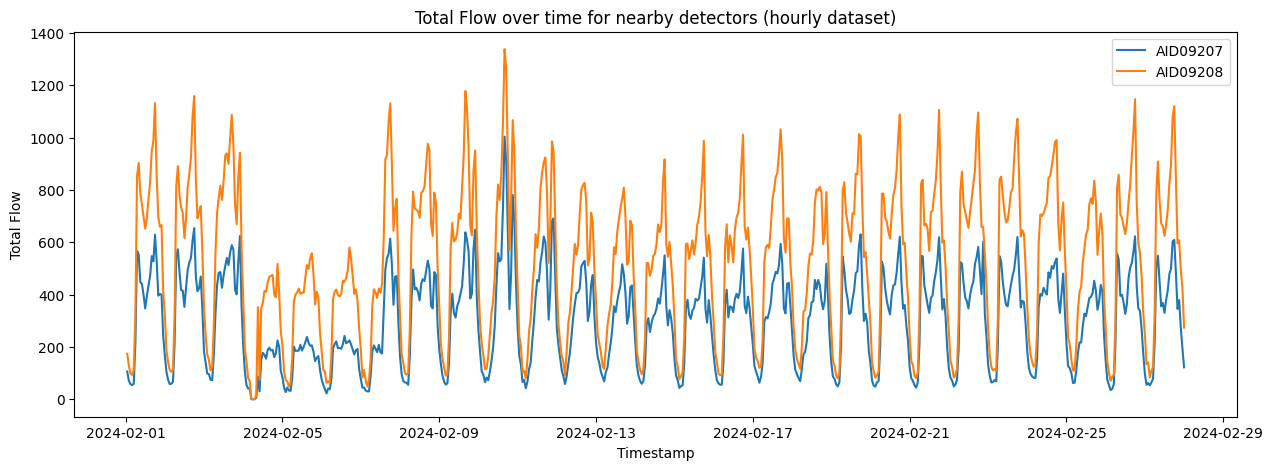

In [45]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(dv5.index, dv5['AID09207_total_flow'],label='AID09207', alpha=1)
ax.plot(dv5.index, dv5['AID09208_total_flow'],label='AID09208', alpha=1)
ax.set_xlabel('Timestamp')
ax.set_ylabel('Total Flow')
ax.set_title('Total Flow over time for nearby detectors (hourly dataset)')

ax.legend()
plt.xticks(rotation=0)
plt.show()

# fig, ax = plt.subplots(figsize=(30, 12))
# ax.plot(ds1.index, ds1['AID09205_avg_speed'],label='AID01212 ', alpha=0.7)
# ax.plot(ds1.index, ds1['AID09206_avg_speed'],label='AID01213 ', alpha=0.7)
# ax.set_xlabel('Timestamp')
# ax.set_ylabel('Total Speed')
# ax.set_title('Total Speed over time for nearby detectors (hourly dataset)')

# ax.legend()
# plt.xticks(rotation=45)
# plt.show()

# fig, ax = plt.subplots(figsize=(30, 12))
# ax.plot(do1.index, do1['AID09205_avg_occupancy'],label='AID01212 ', alpha=0.7)
# ax.plot(do1.index, do1['AID09206_avg_occupancy'],label='AID01213 ', alpha=0.7)
# ax.set_xlabel('Timestamp')
# ax.set_ylabel('Total Occ')
# ax.set_title('Total Occ over time for nearby detectors (hourly dataset)')

# ax.legend()
# plt.xticks(rotation=10)
# plt.show()

In [41]:
calculate_correlation(dfv, 'TDS90022_total_flow', 'TDS90024_total_flow', '2023-12-01', '2024-01-30')

0.9138514046051143

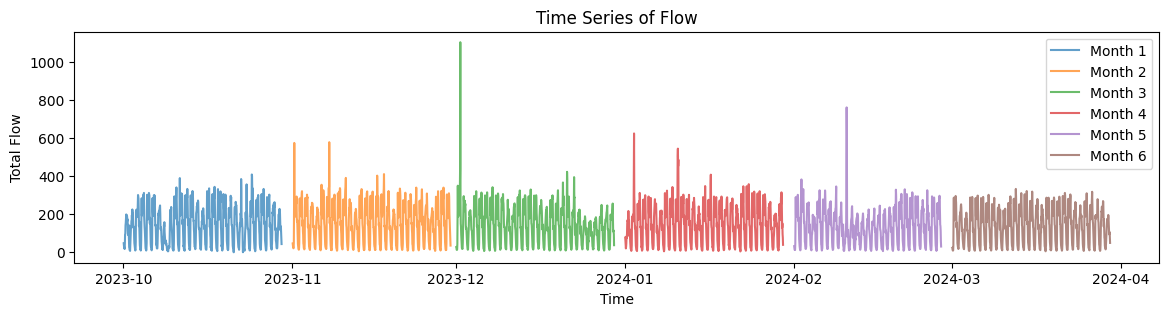

In [47]:
# for i in range(6, 0,-1):
    # Create a new figure and axis object for each plot
    # fig, ax = plt.subplots(figsize=(14, 3))
fig, ax = plt.subplots(figsize=(14, 3))
# Plot the time series for each month up to i
for j in range(1, 7):
    # Get the corresponding DataFrame
    df = globals()[f'dv{j}']
    
    # Assuming the DataFrame has a 'time' column and 'AID01118_lane2' column
    ax.plot(df.index, df['TDSTPR20004_total_flow'], label=f'Month {j}', alpha=0.7)

ax.set_xlabel('Time')
ax.set_ylabel('Total Flow')
ax.set_title(f'Time Series of Flow')
ax.legend()
plt.xticks(rotation=0)
plt.show()

# fig, ax = plt.subplots(figsize=(14, 3))
# # Plot the time series for each month up to i
# for j in range(1, 7):
#     # Get the corresponding DataFrame
#     df = globals()[f'ds{j}']
    
#     # Assuming the DataFrame has a 'time' column and 'AID01118_lane2' column
#     ax.plot(df.index, df['AID09118_avg_speed'], label=f'Month {j}', alpha=0.7)

# ax.set_xlabel('Time')
# ax.set_ylabel('Flow')
# ax.set_title(f'Time Series of Speed for Months 1 to {i}')
# ax.legend()
# plt.xticks(rotation=45)
# plt.show()

# fig, ax = plt.subplots(figsize=(14, 3))
# # Plot the time series for each month up to i
# for j in range(1, 7):
#     # Get the corresponding DataFrame
#     df = globals()[f'do{j}']
    
#     # Assuming the DataFrame has a 'time' column and 'AID01118_lane2' column
#     ax.plot(df.index, df['AID09102_avg_occupancy']-df['AID09101_avg_occupancy'], label=f'Month {j}', alpha=0.7)

# ax.set_xlabel('Time')
# ax.set_ylabel('Flow')
# ax.set_title(f'Time Series of Flow for Months 1 to {i}')
# ax.legend()
# plt.xticks(rotation=45)
# plt.show()

# Data Manupulation

In [42]:
# import os
# import pandas as pd

# # Define the path to the main folder containing the monthly folders
# main_folder_path = 'Z:/Hong Kong PolyU/Assignment_2/HKdata-fromTD/TD57(10.23-03.24)'

# # Get all the folder names within the main folder
# month_folders = [f for f in os.listdir(main_folder_path) if os.path.isdir(os.path.join(main_folder_path, f))]

# # Dictionary to store combined data for each detector
# combined_data = {}

# # Iterate through each month's folder
# for month_folder in month_folders:
#     month_folder_path = os.path.join(main_folder_path, month_folder)
    
#     # Iterate through each CSV file in the month folder
#     for csv_file in os.listdir(month_folder_path):
#         if csv_file.endswith('.csv'):
#             # Extract the detector name before the underscore
#             detector_name = csv_file.split('_')[0]
#             csv_file_path = os.path.join(month_folder_path, csv_file)
            
#             # Read the CSV file
#             df = pd.read_csv(csv_file_path)
            
#             # Combine the data
#             if detector_name not in combined_data:
#                 combined_data[detector_name] = df
#             else:
#                 combined_data[detector_name] = pd.concat([combined_data[detector_name], df])

# # Output folder to save combined CSV files
# output_folder = os.path.join(main_folder_path, 'TD57_2023.10-2024.03')
# os.makedirs(output_folder, exist_ok=True)

# # Save the combined data for each detector to a new CSV file
# for detector_name, combined_df in combined_data.items():
#     output_file_path = os.path.join(output_folder, f'{detector_name}.csv')
#     combined_df.to_csv(output_file_path, index=False)

# print(f"Combined data saved to {output_folder}")

In [43]:
# import os
# import pandas as pd

# # Define the path to the main folder containing the monthly folders
# main_folder_path = 'Z:/Hong Kong PolyU/Assignment_2/HKdata-fromTD/TD93(10.23-03.24)'

# # Get all the folder names within the main folder
# month_folders = [f for f in os.listdir(main_folder_path) if os.path.isdir(os.path.join(main_folder_path, f))]

# # Dictionary to store combined data for each detector
# combined_data = {}

# # Known header for the CSV files
# known_header = ['_device_id', 'timestamp', 'speed_lane_6', 'speed_lane_5', 'speed_lane_4', 'speed_lane_3', 'speed_lane_2', 'speed_lane_1', 'average_speed', 'flow_lane_6', 'flow_lane_5', 'flow_lane_4', 'flow_lane_3', 'flow_lane_2', 'flow_lane_1', 'total_flow', 'occupancy_lane_6', 'occupancy_lane_5', 'occupancy_lane_4', 'occupancy_lane_3', 'occupancy_lane_2', 'occupancy_lane_1', 'avg_occupancy', 'short_vehicle_flow_lane_6', 'short_vehicle_flow_lane_5', 'short_vehicle_flow_lane_4', 'short_vehicle_flow_lane_3', 'short_vehicle_flow_lane_2', 'short_vehicle_flow_lane_1', 'medium_vehicle_flow_lane_6', 'medium_vehicle_flow_lane_5', 'medium_vehicle_flow_lane_4', 'medium_vehicle_flow_lane_3', 'medium_vehicle_flow_lane_2', 'medium_vehicle_flow_lane_1', 'long_vehicle_flow_lane_6', 'long_vehicle_flow_lane_5', 'long_vehicle_flow_lane_4', 'long_vehicle_flow_lane_3', 'long_vehicle_flow_lane_2', 'long_vehicle_flow_lane_1', 'extra_long_vehicle_flow_lane_6', 'extra_long_vehicle_flow_lane_5', 'extra_long_vehicle_flow_lane_4', 'extra_long_vehicle_flow_lane_3', 'extra_long_vehicle_flow_lane_2', 'extra_long_vehicle_flow_lane_1']

# # Iterate through each month's folder
# for month_folder in month_folders:
#     month_folder_path = os.path.join(main_folder_path, month_folder)
    
#     # Iterate through each CSV file in the month folder
#     for csv_file in os.listdir(month_folder_path):
#         if csv_file.endswith('.csv'):
#             # Extract the detector name before the underscore
#             detector_name = csv_file.split('_')[0]
#             csv_file_path = os.path.join(month_folder_path, csv_file)
            
#             # Read the CSV file excluding the last line
#             df = pd.read_csv(csv_file_path, skipfooter=1, engine='python', names=known_header, header=None)
            
#             # Combine the data
#             if detector_name not in combined_data:
#                 combined_data[detector_name] = df
#             else:
#                 combined_data[detector_name] = pd.concat([combined_data[detector_name], df], ignore_index=True)

# # Output folder to save combined CSV files
# output_folder = os.path.join(main_folder_path, 'TD93_2023.10-2024.03')
# os.makedirs(output_folder, exist_ok=True)

# # Save the combined data for each detector to a new CSV file
# for detector_name, combined_df in combined_data.items():
#     output_file_path = os.path.join(output_folder, f'{detector_name}.csv')
#     combined_df.to_csv(output_file_path, index=False)

# print(f"Combined data saved to {output_folder}")


In [44]:
# import os
# import pandas as pd

# # Define the path to the main folder containing the CSV files
# main_folder_path = 'Z:/Hong Kong PolyU/Assignment_2/HKdata-fromTD/10.23-03.24'

# # List to store the combined speed, flow, and occupancy data
# combined_speed_data = []
# combined_flow_data = []
# combined_occupancy_data = []

# # List to store the count of non-empty lanes for each detector
# lane_count_data = []

# all_timestamps = list(pd.date_range(start='2023-10-01 00:00:00', end='2024-03-31 23:58:00', freq='2min'))
# all_timestamps = [str(i) for i in all_timestamps]
# # # Define a set to keep track of all timestamps
# # all_timestamps = set()

# # # First pass to collect all timestamps from one file (assuming all files have the same timestamp range)
# # csv_file_path = os.path.join(main_folder_path, 'AID01101.csv')
# # df = pd.read_csv(csv_file_path)
# # if 'timestamp' in df.columns:
# #     all_timestamps.update(df['timestamp'].values)

# # # Create a sorted list of all unique timestamps
# # all_timestamps = sorted(all_timestamps)

# # Create a DataFrame with all timestamps
# combined_speed_df = pd.DataFrame({'timestamp': all_timestamps})
# combined_flow_df = pd.DataFrame({'timestamp': all_timestamps})
# combined_occupancy_df = pd.DataFrame({'timestamp': all_timestamps})

# # Second pass to collect speed, flow, and occupancy data
# for csv_file in os.listdir(main_folder_path):
#     if csv_file.endswith('.csv'):
#         # Extract the detector name before the underscore
#         detector_name = csv_file.split('.')[0]
#         csv_file_path = os.path.join(main_folder_path, csv_file)
        
#         # Read the CSV file
#         df = pd.read_csv(csv_file_path)
        
#         # Initialize dictionaries to store the data for this detector
#         speed_data = {'timestamp': all_timestamps}
#         flow_data = {'timestamp': all_timestamps}
#         occupancy_data = {'timestamp': all_timestamps}
#         speed_lane_count = 0
#         flow_lane_count = 0
#         occupancy_lane_count = 0
        
#         # Check each speed lane and average speed column
#         for lane in range(1, 7):
#             speed_column_name = f'speed_lane_{lane}'
#             flow_column_name = f'flow_lane_{lane}'
#             occupancy_column_name = f'occupancy_lane_{lane}'
            
#             if speed_column_name in df.columns and not df[speed_column_name].isna().all():
#                 df_lane = df[['timestamp', speed_column_name]].dropna()
#                 df_lane.columns = ['timestamp', f'{detector_name}_lane{lane}_speed']
#                 df_lane = df_lane.set_index('timestamp').reindex(all_timestamps).reset_index()
#                 speed_data[f'{detector_name}_lane{lane}_speed'] = df_lane[f'{detector_name}_lane{lane}_speed']
#                 speed_lane_count += 1
                
#             if flow_column_name in df.columns and not df[flow_column_name].isna().all():
#                 df_lane = df[['timestamp', flow_column_name]].dropna()
#                 df_lane.columns = ['timestamp', f'{detector_name}_lane{lane}_flow']
#                 df_lane = df_lane.set_index('timestamp').reindex(all_timestamps).reset_index()
#                 flow_data[f'{detector_name}_lane{lane}_flow'] = df_lane[f'{detector_name}_lane{lane}_flow']
#                 flow_lane_count += 1
                
#             if occupancy_column_name in df.columns and not df[occupancy_column_name].isna().all():
#                 df_lane = df[['timestamp', occupancy_column_name]].dropna()
#                 df_lane.columns = ['timestamp', f'{detector_name}_lane{lane}_occupancy']
#                 df_lane = df_lane.set_index('timestamp').reindex(all_timestamps).reset_index()
#                 occupancy_data[f'{detector_name}_lane{lane}_occupancy'] = df_lane[f'{detector_name}_lane{lane}_occupancy']
#                 occupancy_lane_count += 1
        
#         # Check the average and total columns
#         avg_speed_column = 'average_speed'
#         total_flow_column = 'total_flow'
#         avg_occupancy_column = 'avg_occupancy'
        
#         if avg_speed_column in df.columns and not df[avg_speed_column].isna().all():
#             df_avg = df[['timestamp', avg_speed_column]].dropna()
#             df_avg.columns = ['timestamp', f'{detector_name}_avg_speed']
#             df_avg = df_avg.set_index('timestamp').reindex(all_timestamps).reset_index()
#             speed_data[f'{detector_name}_avg_speed'] = df_avg[f'{detector_name}_avg_speed']
            
#         if total_flow_column in df.columns and not df[total_flow_column].isna().all():
#             df_total = df[['timestamp', total_flow_column]].dropna()
#             df_total.columns = ['timestamp', f'{detector_name}_total_flow']
#             df_total = df_total.set_index('timestamp').reindex(all_timestamps).reset_index()
#             flow_data[f'{detector_name}_total_flow'] = df_total[f'{detector_name}_total_flow']
            
#         if avg_occupancy_column in df.columns and not df[avg_occupancy_column].isna().all():
#             df_avg = df[['timestamp', avg_occupancy_column]].dropna()
#             df_avg.columns = ['timestamp', f'{detector_name}_avg_occupancy']
#             df_avg = df_avg.set_index('timestamp').reindex(all_timestamps).reset_index()
#             occupancy_data[f'{detector_name}_avg_occupancy'] = df_avg[f'{detector_name}_avg_occupancy']
            
#         # If we have any valid data, add it to the combined data
#         if len(speed_data) > 1:  # More than just timestamps
#             combined_speed_data.append(pd.DataFrame(speed_data))
#         if len(flow_data) > 1:  # More than just timestamps
#             combined_flow_data.append(pd.DataFrame(flow_data))
#         if len(occupancy_data) > 1:  # More than just timestamps
#             combined_occupancy_data.append(pd.DataFrame(occupancy_data))
        
#         lane_count_truth = False
#         if(speed_lane_count==flow_lane_count and flow_lane_count==occupancy_lane_count):
#             lane_count_truth = True 

#         lane_count_data.append({
#             'detector': detector_name,
#             'speed_lane_count': speed_lane_count,
#             'flow_lane_count': flow_lane_count,
#             'occupancy_lane_count': occupancy_lane_count,
#             'is_same' : lane_count_truth
#         })

# # Merge all dataframes on 'timestamp'
# for speed_df in combined_speed_data:
#     combined_speed_df = combined_speed_df.merge(speed_df, on='timestamp', how='left')

# for flow_df in combined_flow_data:
#     combined_flow_df = combined_flow_df.merge(flow_df, on='timestamp', how='left')

# for occupancy_df in combined_occupancy_data:
#     combined_occupancy_df = combined_occupancy_df.merge(occupancy_df, on='timestamp', how='left')

# # Create a dataframe for the lane counts
# lane_count_df = pd.DataFrame(lane_count_data)

# # Define the output paths
# output_speed_csv = os.path.join(main_folder_path +'/combined', 'speed_10.23-03.24.csv')
# output_flow_csv = os.path.join(main_folder_path +'/combined', 'flow_10.23-03.24.csv')
# output_occupancy_csv = os.path.join(main_folder_path +'/combined', 'occupancy_10.23-03.24.csv')
# output_lane_count_csv = os.path.join(main_folder_path +'/combined', 'lane_10.23-03.24.csv')

# # Save the combined data to new CSV files
# combined_speed_df.to_csv(output_speed_csv, index=False)
# combined_flow_df.to_csv(output_flow_csv, index=False)
# combined_occupancy_df.to_csv(output_occupancy_csv, index=False)
# lane_count_df.to_csv(output_lane_count_csv, index=False)

# print(f"Combined speed data saved to {output_speed_csv}")
# print(f"Combined flow data saved to {output_flow_csv}")
# print(f"Combined occupancy data saved to {output_occupancy_csv}")
# print(f"Lane count data saved to {output_lane_count_csv}")


In [45]:
# combined_data = {}

# for csv_file in os.listdir('Z:/Hong Kong PolyU/Assignment_2/HKdata-fromTD/10.23-03.24'):
#         if csv_file.endswith('.csv'):
#             # Extract the detector name before the underscore
#             detector_name = os.path.splitext(csv_file)[0]
#             csv_file_path = os.path.join('Z:/Hong Kong PolyU/Assignment_2/HKdata-fromTD/10.23-03.24', csv_file)
            
#             # Read the CSV file
#             df = pd.read_csv(csv_file_path)
#             df.loc[:,'timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
#             df.set_index("timestamp",inplace=True)
            
#             # Combine the data
#             if detector_name not in combined_data:
#                 combined_data[detector_name] = df

# Wavelet Decomposition

In [50]:
# import random

# # Function to plot flow vs occupancy for randomly chosen detectors and lanes
# def plot_random_flow_vs_occupancy(combined_data):
#     detectors = list(combined_data.keys())
#     chosen_detectors = random.sample(detectors, 12)
#     # chosen_detectors = detectors[:12]
    
#     fig, axes = plt.subplots(nrows=2, ncols=6, figsize=(20, 7))
#     axes = axes.flatten()  # Flatten the 2D array of axes to simplify indexing

#     for i, detector in enumerate(chosen_detectors):
#         df = combined_data[detector]
        
#         if 'occupancy_lane_1' in df.columns and 'flow_lane_1' in df.columns:
#             ax = axes[i]
#             ax.scatter(df['occupancy_lane_1'], df['flow_lane_1'], alpha=0.5,s=0.5)
#             ax.set_title(f'Flow vs Occupancy for {detector}')
#             ax.set_xlabel('Occupancy')
#             ax.set_ylabel('Flow')
#             ax.grid(True)
#         else:
#             print(f"Detector {detector} does not have 'occupancy_lane_1' and 'flow_lane_1' columns")

#     plt.tight_layout()
#     plt.show()

# # Example usage
# # Assuming combined_data is your dictionary containing DataFrames for each detector
# plot_random_flow_vs_occupancy(combined_data)


In [49]:
# import pywt

# detector_name = 'AID01115'
# feature = 'speed_lane_1'  # Replace with the actual feature name
# time_series = combined_data[detector_name][feature].dropna()  # Drop NaN values

# # Perform wavelet decomposition
# wavelet = 'haar'  # You can choose other wavelet types like 'haar', 'db4', etc.
# level = 5  # Decomposition level, you can adjust this

# coeffs = pywt.wavedec(time_series, wavelet, level=level)

# # Plot the decomposition results
# fig, axes = plt.subplots(nrows=len(coeffs), ncols=1, figsize=(10, 12))

# for i, ax in enumerate(axes):
#     ax.plot(coeffs[i])
#     ax.set_title(f'Wavelet Coefficient - Level {i}')

# plt.tight_layout()
# plt.show()

# # Example to reconstruct the signal from wavelet coefficients
# reconstructed_signal = pywt.waverec(coeffs, wavelet)

# # Plot original and reconstructed signals
# plt.figure(figsize=(10, 6))
# plt.plot(time_series, label='Original Signal')
# plt.plot(reconstructed_signal, label='Reconstructed Signal', linestyle='--')
# plt.legend()
# plt.title('Original and Reconstructed Signals')
# plt.show()


In [48]:
# datafr = pd.read_csv("Z:/Hong Kong PolyU/Assignment_2/HKdata-fromTD/TD93(10.23-03.24)/TD93_AID_202312/TDS-IEC-20002_2023-12-01_2023-12-31.csv")
# headers = list(datafr)
# print(headers)